In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('demand_forecasting_dataset.csv')

In [7]:
df

,date,product_id,category_id,store_id,historical_sales,price,promotion_flag,holiday_flag,economic_index,target_demand
0,2022-01-02,1043,4,9,16,48.29,0,0,84.07,8
1,2022-01-02,1012,4,2,25,44.01,0,0,106.87,22
2,2022-01-03,1003,5,4,26,9.44,1,0,104.98,29
3,2022-01-03,1005,4,1,23,5.42,1,1,92.75,22
4,2022-01-04,1011,1,5,12,21.86,1,1,103.60,27
...,...,...,...,...,...,...,...,...,...,...
4916,2035-06-19,1018,5,7,25,35.46,1,0,102.21,32
4917,2035-06-19,1029,5,4,21,15.05,0,1,82.47,17
4918,2035-06-19,1019,5,10,24,43.68,0,1,99.41,19
4919,2035-06-19,1027,5,4,23,25.52,0,0,93.95,22


In [9]:
print("="*60)
print("First 5 Records")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("Last 5 Records")
print("="*60)

print(df.tail())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)

print(df.columns)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("\n")

print("="*60)
print("Data Types")
print("="*60)

print(df.dtypes)

First 5 Records
         date  product_id  category_id  store_id  historical_sales  price  \
0  2022-01-02        1043            4         9                16  48.29   
1  2022-01-02        1012            4         2                25  44.01   
2  2022-01-03        1003            5         4                26   9.44   
3  2022-01-03        1005            4         1                23   5.42   
4  2022-01-04        1011            1         5                12  21.86   

   promotion_flag  holiday_flag  economic_index  target_demand  
0               0             0           84.07              8  
1               0             0          106.87             22  
2               1             0          104.98             29  
3               1             1           92.75             22  
4               1             1          103.60             27  


Last 5 Records
            date  product_id  category_id  store_id  historical_sales  price  \
4916  2035-06-19        1018      

In [10]:
print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())



Missing Values
date                0
product_id          0
category_id         0
store_id            0
historical_sales    0
price               0
promotion_flag      0
holiday_flag        0
economic_index      0
target_demand       0
dtype: int64


In [11]:
print("\n")

print("="*60)
print("Duplicate Records")
print("="*60)

print(df.duplicated().sum())



Duplicate Records
0


In [12]:
print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)

print(df.describe())



Statistical Summary
        product_id  category_id     store_id  historical_sales        price  \
count  4921.000000  4921.000000  4921.000000       4921.000000  4921.000000   
mean   1024.328389     3.018492     5.453363         20.039626    27.209683   
std      14.297004     1.422905     2.883354          4.398985    12.923657   
min    1000.000000     1.000000     1.000000          5.000000     5.000000   
25%    1012.000000     2.000000     3.000000         17.000000    15.950000   
50%    1024.000000     3.000000     5.000000         20.000000    27.120000   
75%    1037.000000     4.000000     8.000000         23.000000    38.370000   
max    1049.000000     5.000000    10.000000         37.000000    49.990000   

       promotion_flag  holiday_flag  economic_index  target_demand  
count     4921.000000   4921.000000     4921.000000    4921.000000  
mean         0.291607      0.152408       99.834089      22.421459  
std          0.454549      0.359452        9.870727       7

In [13]:
df["date"] = pd.to_datetime(df["date"])

print("\nDate Converted Successfully")


Date Converted Successfully


In [14]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

print(df.head())

        date  product_id  category_id  store_id  historical_sales  price  \
0 2022-01-02        1043            4         9                16  48.29   
1 2022-01-02        1012            4         2                25  44.01   
2 2022-01-03        1003            5         4                26   9.44   
3 2022-01-03        1005            4         1                23   5.42   
4 2022-01-04        1011            1         5                12  21.86   

   promotion_flag  holiday_flag  economic_index  target_demand  year  month  \
0               0             0           84.07              8  2022      1   
1               0             0          106.87             22  2022      1   
2               1             0          104.98             29  2022      1   
3               1             1           92.75             22  2022      1   
4               1             1          103.60             27  2022      1   

   day  
0    2  
1    2  
2    3  
3    3  
4    4  


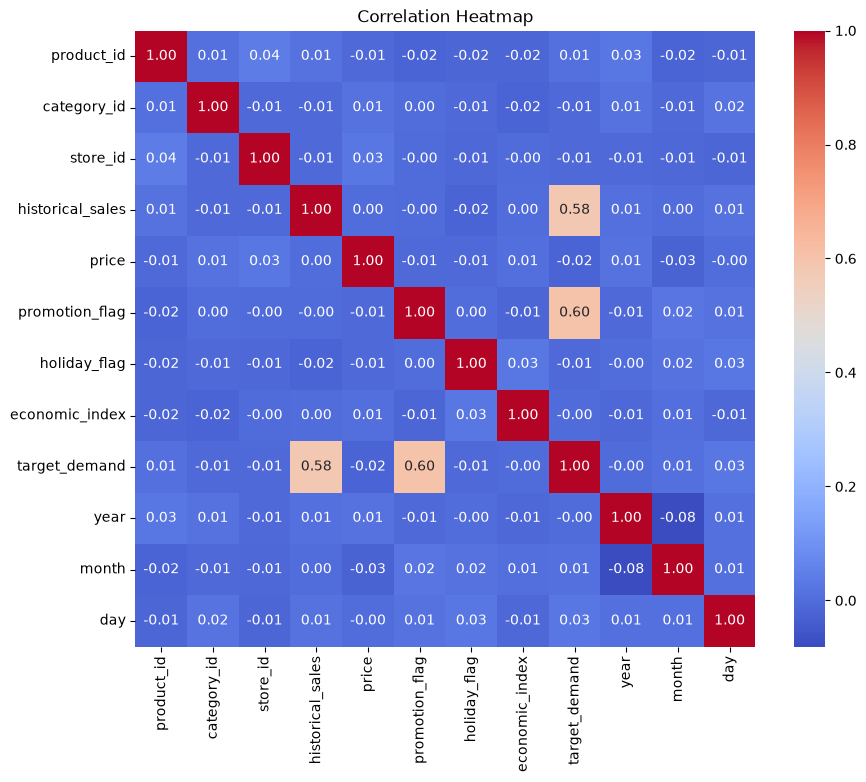

In [15]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(

    correlation,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Heatmap")

plt.show()

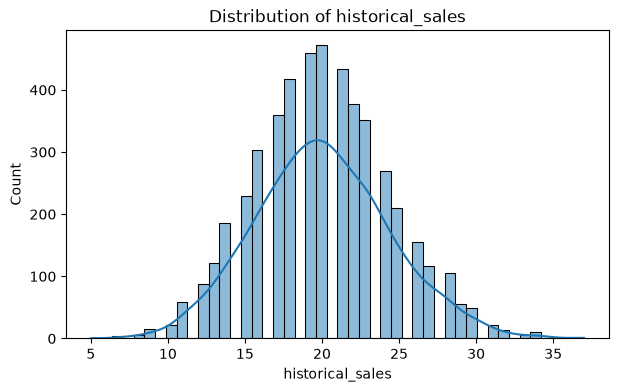

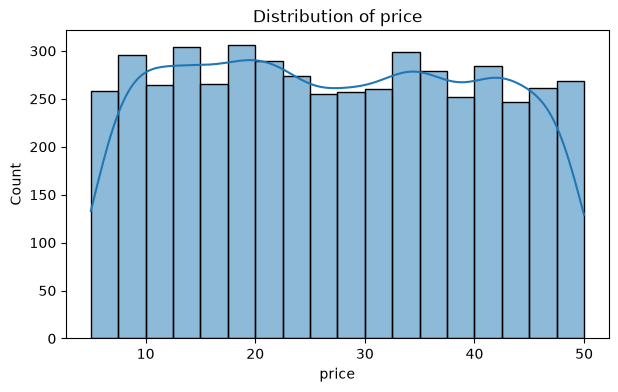

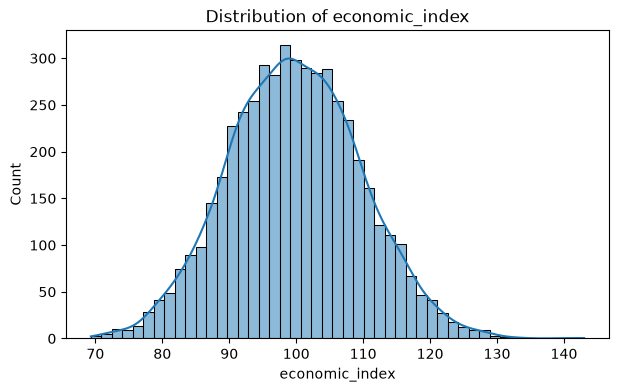

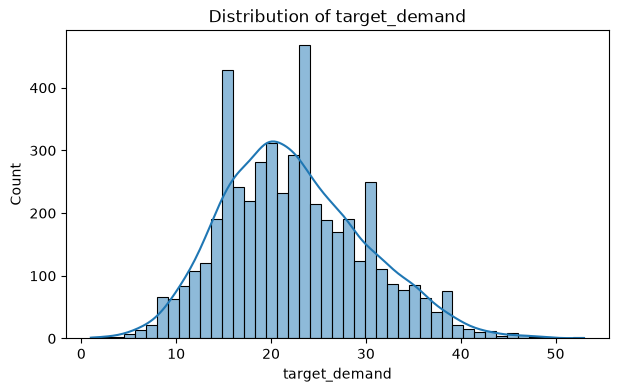

In [16]:
numerical_columns = [

    "historical_sales",

    "price",

    "economic_index",

    "target_demand"

]

for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(

        df[col],

        kde=True

    )

    plt.title(f"Distribution of {col}")

    plt.show()

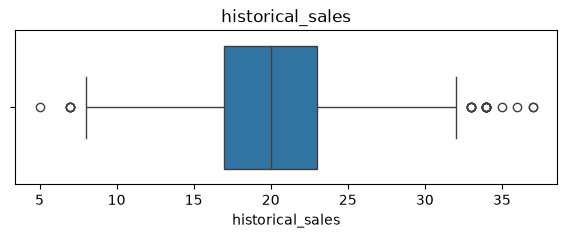

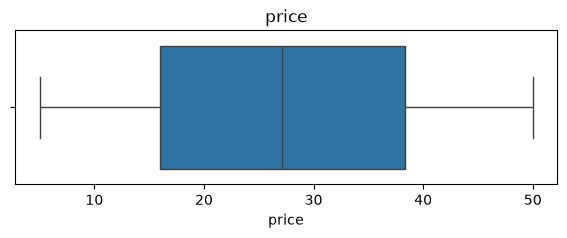

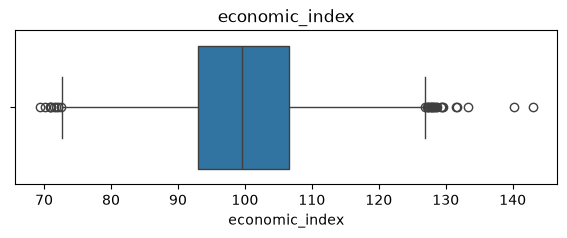

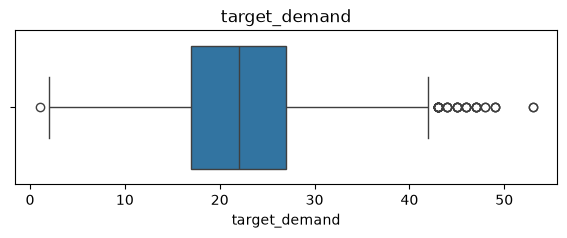

In [17]:
for col in numerical_columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(

        x=df[col]

    )

    plt.title(col)

    plt.show()

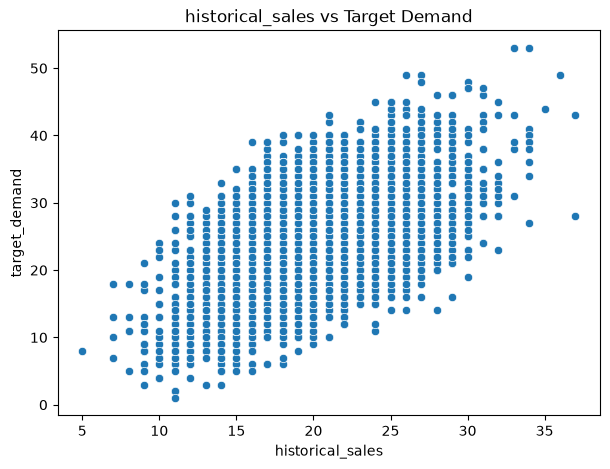

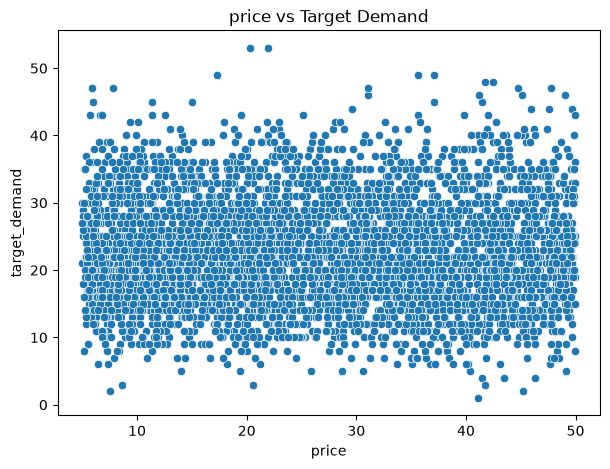

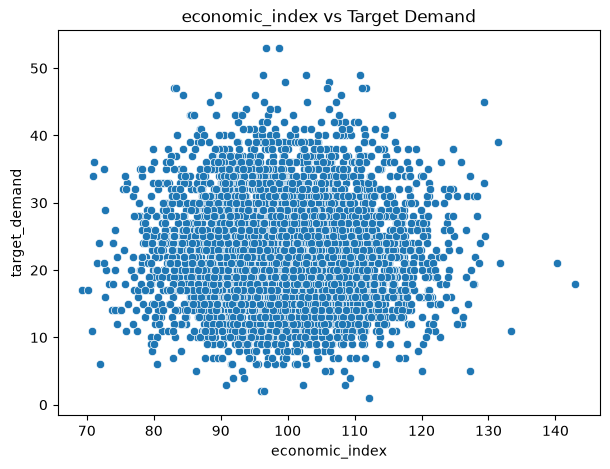

In [18]:
features = [

    "historical_sales",

    "price",

    "economic_index"

]

for feature in features:

    plt.figure(figsize=(7,5))

    sns.scatterplot(

        data=df,

        x=feature,

        y="target_demand"

    )

    plt.title(f"{feature} vs Target Demand")

    plt.show()

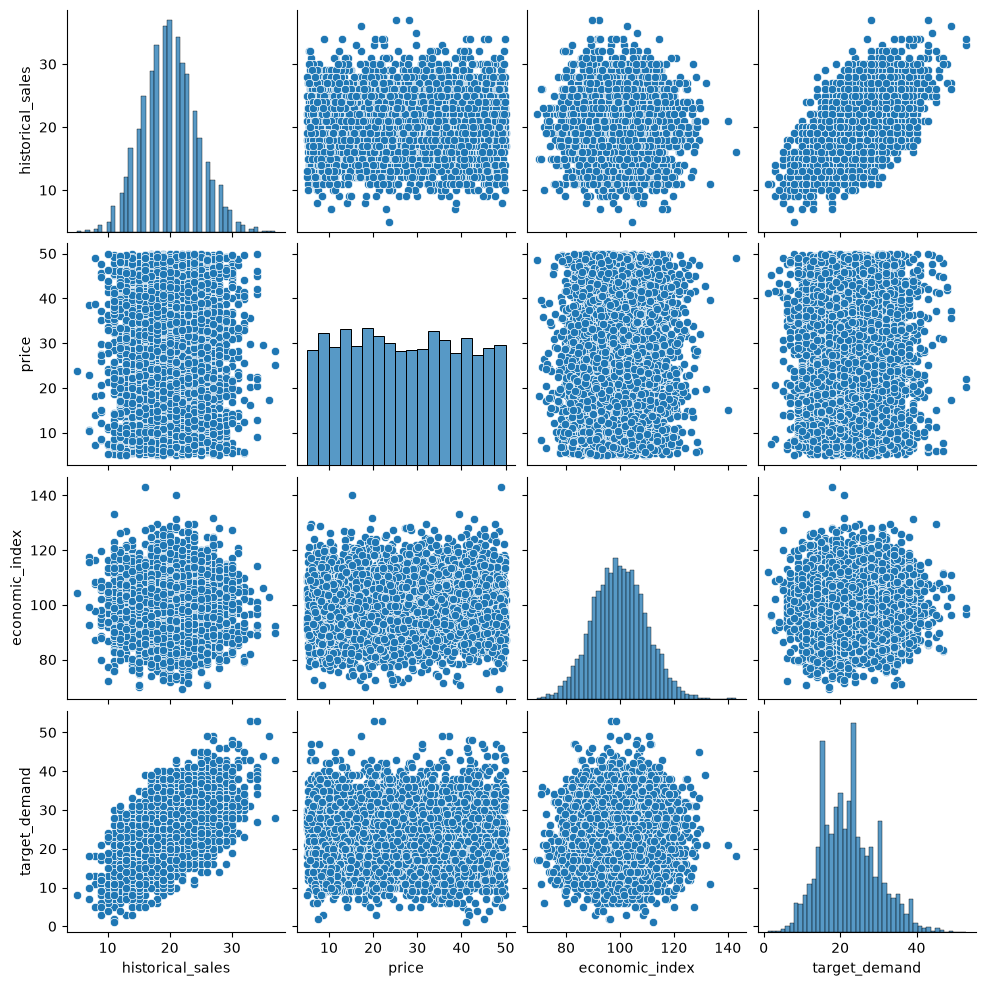

In [19]:
sns.pairplot(

    df[

        [

            "historical_sales",

            "price",

            "economic_index",

            "target_demand"

        ]

    ]

)

plt.show()

In [20]:
X = df[

    [

        "historical_sales",

        "price",

        "promotion_flag",

        "holiday_flag",

        "economic_index"

    ]

]

y = df["target_demand"]

print("\n")

print("="*60)
print("Selected Features")
print("="*60)

print(X.head())

print("\n")

print("="*60)
print("Target Variable")
print("="*60)

print(y.head())

print("\n")

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)

print("\n")

print("="*60)



Selected Features
   historical_sales  price  promotion_flag  holiday_flag  economic_index
0                16  48.29               0             0           84.07
1                25  44.01               0             0          106.87
2                26   9.44               1             0          104.98
3                23   5.42               1             1           92.75
4                12  21.86               1             1          103.60


Target Variable
0     8
1    22
2    29
3    22
4    27
Name: target_demand, dtype: int64


Input Shape : (4921, 5)
Target Shape: (4921,)




In [21]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("="*60)
print("Training Shape")
print("="*60)

print(X_train.shape)
print(y_train.shape)

Training Shape
(3936, 5)
(3936,)


In [22]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(

    X_train,

    y_train

)

# Predictions

linear_train_predictions = linear_model.predict(X_train)

linear_test_predictions = linear_model.predict(X_test)

In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(

    degree=2,

    include_bias=False

)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("\n")

print("="*60)
print("Original Features")
print("="*60)

print(X_train.shape)

print("\n")

print("="*60)
print("Polynomial Features")
print("="*60)

print(X_train_poly.shape)



Original Features
(3936, 5)


Polynomial Features
(3936, 20)


In [24]:
poly_model = LinearRegression()

poly_model.fit(

    X_train_poly,

    y_train

)

print("\nPolynomial Regression Model Trained Successfully!")


Polynomial Regression Model Trained Successfully!


In [25]:
poly_train_predictions = poly_model.predict(

    X_train_poly

)

poly_test_predictions = poly_model.predict(

    X_test_poly

)

In [26]:
from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

In [27]:
linear_train_r2 = r2_score(

    y_train,

    linear_train_predictions

)

linear_test_r2 = r2_score(

    y_test,

    linear_test_predictions

)

In [28]:
poly_train_r2 = r2_score(

    y_train,

    poly_train_predictions

)

poly_test_r2 = r2_score(

    y_test,

    poly_test_predictions

)

poly_mae = mean_absolute_error(

    y_test,

    poly_test_predictions

)

poly_mse = mean_squared_error(

    y_test,

    poly_test_predictions

)

poly_rmse = np.sqrt(poly_mse)

In [29]:
print("\n")

print("="*70)
print("Linear Regression")
print("="*70)

print(f"Train R2 : {linear_train_r2:.4f}")

print(f"Test R2  : {linear_test_r2:.4f}")

print("\n")

print("="*70)
print("Polynomial Regression")
print("="*70)

print(f"Train R2 : {poly_train_r2:.4f}")

print(f"Test R2  : {poly_test_r2:.4f}")

print(f"MAE      : {poly_mae:.2f}")

print(f"MSE      : {poly_mse:.2f}")

print(f"RMSE     : {poly_rmse:.2f}")



Linear Regression
Train R2 : 0.7025
Test R2  : 0.6942


Polynomial Regression
Train R2 : 0.7032
Test R2  : 0.6934
MAE      : 3.36
MSE      : 17.48
RMSE     : 4.18


In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(

    poly_model,

    poly.fit_transform(X),

    y,

    cv=5,

    scoring="r2"

)

print("\n")

print("="*70)
print("Cross Validation")
print("="*70)

print(cv_scores)

print("\nAverage Score")

print(cv_scores.mean())



Cross Validation
[0.68802584 0.70675139 0.68052373 0.70801078 0.71078133]

Average Score
0.6988186147631489


In [31]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Polynomial Regression"

    ],

    "Train R2":[

        linear_train_r2,

        poly_train_r2

    ],

    "Test R2":[

        linear_test_r2,

        poly_test_r2

    ]

})

print("\n")

print("="*70)
print("Model Comparison")
print("="*70)

print(comparison)



Model Comparison
                   Model  Train R2   Test R2
0      Linear Regression  0.702509  0.694215
1  Polynomial Regression  0.703167  0.693441


In [33]:
if poly_test_r2 > linear_test_r2:

    print("\nPolynomial Regression performed better!")

else:

    print("\nLinear Regression performed better!")

print("\n")




Linear Regression performed better!




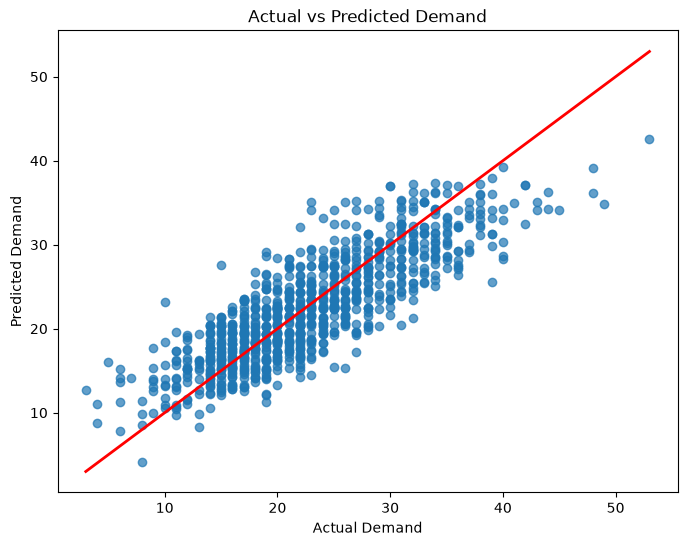

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    poly_test_predictions,

    alpha=0.7

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Demand")

plt.ylabel("Predicted Demand")

plt.title("Actual vs Predicted Demand")

plt.show()

In [35]:
residuals = y_test - poly_test_predictions

print("="*60)
print("First 10 Residuals")
print("="*60)

print(residuals.head(10))

First 10 Residuals
373     1.558430
4917   -3.824328
1550   -0.263021
3081   -6.299959
4441    2.463212
926    -9.201617
2575   -8.471785
765    -2.378159
3752    0.617551
4194    6.244760
Name: target_demand, dtype: float64


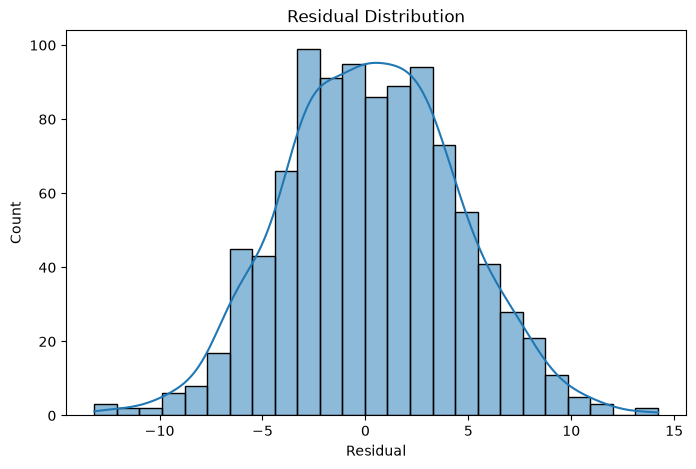

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(

    residuals,

    kde=True

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.show()

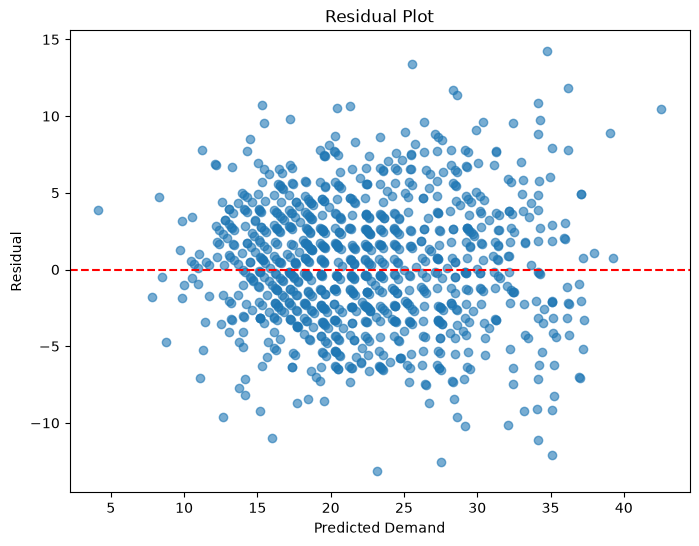

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(

    poly_test_predictions,

    residuals,

    alpha=0.6

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Demand")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

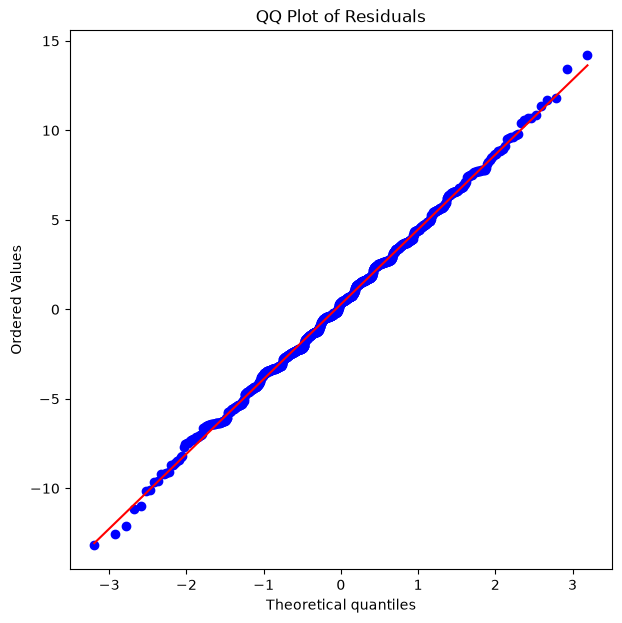

In [38]:
import scipy.stats as stats

plt.figure(figsize=(7,7))

stats.probplot(

    residuals,

    dist="norm",

    plot=plt

)

plt.title("QQ Plot of Residuals")

plt.show()

In [39]:
print("\nResidual Skewness")

print(residuals.skew())


Residual Skewness
0.04280120154067565


In [40]:
comparison = pd.DataFrame({

    "Actual Demand": y_test.values,

    "Predicted Demand": poly_test_predictions

})

print("\n")

print("="*60)
print("Sample Predictions")
print("="*60)

print(comparison.head(10))



Sample Predictions
   Actual Demand  Predicted Demand
0             27         25.441570
1             17         20.824328
2             34         34.263021
3             17         23.299959
4             35         32.536788
5              6         15.201617
6             10         18.471785
7             22         24.378159
8             22         21.382449
9             33         26.755240


In [41]:
new_data = pd.DataFrame({

    "historical_sales":[25],

    "price":[20.5],

    "promotion_flag":[1],

    "holiday_flag":[0],

    "economic_index":[95.5]

})

In [42]:
new_data_poly = poly.transform(new_data)

In [43]:
predicted_demand = poly_model.predict(new_data_poly)

print("\n")

print("="*60)
print("Predicted Demand")
print("="*60)

print(predicted_demand)



Predicted Demand
[34.10128045]


In [44]:
from joblib import dump
dump(

    poly_model,

    "polynomial_regression_model.joblib"

)
dump(

    poly,

    "polynomial_features.joblib"

)

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [45]:
from joblib import load

loaded_model = load(

    "polynomial_regression_model.joblib"

)

loaded_poly = load(

    "polynomial_features.joblib"

)

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


In [46]:
loaded_prediction = loaded_model.predict(

    loaded_poly.transform(new_data)

)

print("\nPrediction Using Loaded Model")

print(loaded_prediction)


Prediction Using Loaded Model
[34.10128045]


In [47]:
print("\n")

print("="*70)
print("Demand Forecasting using Polynomial Regression")
print("="*70)

print(f"Training Samples          : {len(X_train)}")

print(f"Testing Samples           : {len(X_test)}")

print(f"Original Features         : {X_train.shape[1]}")

print(f"Polynomial Features       : {X_train_poly.shape[1]}")

print(f"\nTrain R2 Score           : {poly_train_r2:.4f}")

print(f"Test R2 Score            : {poly_test_r2:.4f}")

print(f"Cross Validation Score   : {cv_scores.mean():.4f}")

print(f"MAE                      : {poly_mae:.2f}")

print(f"RMSE                     : {poly_rmse:.2f}")

print("\nPolynomial Degree        : 2")

print("\nModel Ready for Deployment!")

print("="*70)

print("\nProject Completed Successfully!")



Demand Forecasting using Polynomial Regression
Training Samples          : 3936
Testing Samples           : 985
Original Features         : 5
Polynomial Features       : 20

Train R2 Score           : 0.7032
Test R2 Score            : 0.6934
Cross Validation Score   : 0.6988
MAE                      : 3.36
RMSE                     : 4.18

Polynomial Degree        : 2

Model Ready for Deployment!

Project Completed Successfully!
